Bussiness Context

- Formula 1 adalah olahraga yang tidak hanya mengandalkan kecepatan pembalap, melainkan juga strategi berbasis data yang sangat presisi. Persaingan sengit antara pembalap dan tim (constructors) ditentukan oleh berbagai variable teknis di dalam dan diluar sirkuit
- Tujuan analisis. Fokus pada pengaruh posisi start (grid position): seberapa besar hasil kualifikasi memengaruhi peluah pembalap untuk mengamankan podium di akhir balapan. Yang kedua efisiensi pit stop, bagaimana durasi pit stop dari masing masing tim berkontribusi terhadap posisi akhir balapan?
- Output yang diharapkan, minimal menghasilkan 6 visualisasi data yang bersih dan beranotasi, memberikan 5 insdight utama beerta 2 rekomendasi strategis terkait performa tim

In [1]:
import pandas as pd

In [2]:
results_df = pd.read_csv(r'C:\Users\shifa\OneDrive\Documents\30 Days Data Scientist Challange\day07\race_results.csv')
drivers_df = pd.read_csv(r'C:\Users\shifa\OneDrive\Documents\30 Days Data Scientist Challange\day07\drivers.csv')
constructors_df = pd.read_csv(r'C:\Users\shifa\OneDrive\Documents\30 Days Data Scientist Challange\day07\constructors.csv')
pit_stops_df = pd.read_csv(r'C:\Users\shifa\OneDrive\Documents\30 Days Data Scientist Challange\day07\pit_stops.csv')

In [4]:
print("--- Ukuran Dataset ---")
print(f"Race Results : {results_df.shape}")
print(f"Drivers      : {drivers_df.shape}")
print(f"Constructors : {constructors_df.shape}")
print(f"Pit Stops    : {pit_stops_df.shape}\n")

print("--- Preview 5 Data Teratas Race Results ---")
results_df.head()

--- Ukuran Dataset ---
Race Results : (1024, 21)
Drivers      : (28, 9)
Constructors : (12, 4)
Pit Stops    : (1726, 9)

--- Preview 5 Data Teratas Race Results ---


,season,round,race_name,date,position,position_text,points,driver_id,driver_code,driver_number,...,driver_nat,constructor_id,constructor,grid_pos,laps,status,time_finished,fastest_lap_time,fastest_lap_rank,avg_speed_kph
0,2024,1,Bahrain Grand Prix,2024-03-02,1,1,26.0,max_verstappen,VER,1,...,Dutch,red_bull,Red Bull,1,57,Finished,1:31:44.742,1:32.608,1.0,210.383
1,2024,1,Bahrain Grand Prix,2024-03-02,2,2,18.0,perez,PER,11,...,Mexican,red_bull,Red Bull,5,57,Finished,+22.457,1:34.364,4.0,206.468
2,2024,1,Bahrain Grand Prix,2024-03-02,3,3,15.0,sainz,SAI,55,...,Spanish,ferrari,Ferrari,4,57,Finished,+25.110,1:34.507,6.0,206.156
3,2024,1,Bahrain Grand Prix,2024-03-02,4,4,12.0,leclerc,LEC,16,...,Monegasque,ferrari,Ferrari,2,57,Finished,+39.669,1:34.090,2.0,207.069
4,2024,1,Bahrain Grand Prix,2024-03-02,5,5,10.0,russell,RUS,63,...,British,mercedes,Mercedes,3,57,Finished,+46.788,1:35.065,12.0,204.946


In [5]:
results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   season            1024 non-null   int64  
 1   round             1024 non-null   int64  
 2   race_name         1024 non-null   object 
 3   date              1024 non-null   object 
 4   position          1024 non-null   int64  
 5   position_text     1024 non-null   object 
 6   points            1024 non-null   float64
 7   driver_id         1024 non-null   object 
 8   driver_code       1024 non-null   object 
 9   driver_number     1024 non-null   int64  
 10  driver_name       1024 non-null   object 
 11  driver_nat        1024 non-null   object 
 12  constructor_id    1024 non-null   object 
 13  constructor       1024 non-null   object 
 14  grid_pos          1024 non-null   int64  
 15  laps              1024 non-null   int64  
 16  status            1024 non-null   object 


In [6]:
pit_stops_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1726 entries, 0 to 1725
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   season            1726 non-null   int64  
 1   round             1726 non-null   int64  
 2   race_name         1726 non-null   object 
 3   driver_id         1726 non-null   object 
 4   stop              1726 non-null   int64  
 5   lap               1726 non-null   int64  
 6   time              1726 non-null   object 
 7   duration_s        1724 non-null   float64
 8   is_red_flag_hold  1726 non-null   bool   
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 109.7+ KB


In [8]:
{results_df.duplicated().sum()}

{np.int64(0)}

In [10]:
{pit_stops_df.duplicated().sum()}

{np.int64(0)}

In [11]:
pit_stops_df = pit_stops_df.dropna(subset=['duration_s'])

In [13]:
kolom_results_terpilih = ['season', 'round', 'driver_name', 'constructor', 'grid_pos', 'position']
results_cleaned = results_df[kolom_results_terpilih].copy()

In [14]:
kolom_pit_terpilih = [
    'season', 'round', 'driver_id', 'stop', 'lap', 'duration_s'
]
pit_stops_cleaned = pit_stops_df[kolom_pit_terpilih].copy()

In [15]:
print("\n--- Hasil Akhir Data Cleaning ---")
print(f"Dimensi Data Results Terpilih  : {results_cleaned.shape}")
print(f"Dimensi Data Pit Stops Terpilih : {pit_stops_cleaned.shape}")


--- Hasil Akhir Data Cleaning ---
Dimensi Data Results Terpilih  : (1024, 6)
Dimensi Data Pit Stops Terpilih : (1724, 6)


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, 'Frekuensi (Jumlah Kejadian)')

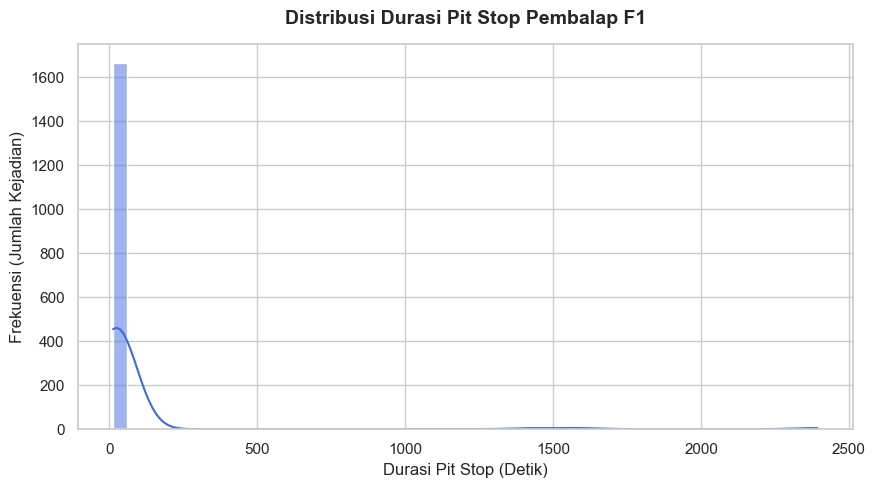

In [18]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.histplot(data=pit_stops_cleaned, x='duration_s', kde=True, bins=50, color='royalblue')

plt.title('Distribusi Durasi Pit Stop Pembalap F1', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Durasi Pit Stop (Detik)', fontsize=12)
plt.ylabel('Frekuensi (Jumlah Kejadian)', fontsize=12)

In [20]:
print(pit_stops_cleaned['duration_s'].describe())

count    1724.000000
mean       76.286247
std       304.978839
min        12.804000
25%        21.686500
50%        23.330000
75%        26.103750
max      2394.053000
Name: duration_s, dtype: float64


In [21]:
pit_normal = pit_stops_cleaned[pit_stops_cleaned['duration_s'] < 50]

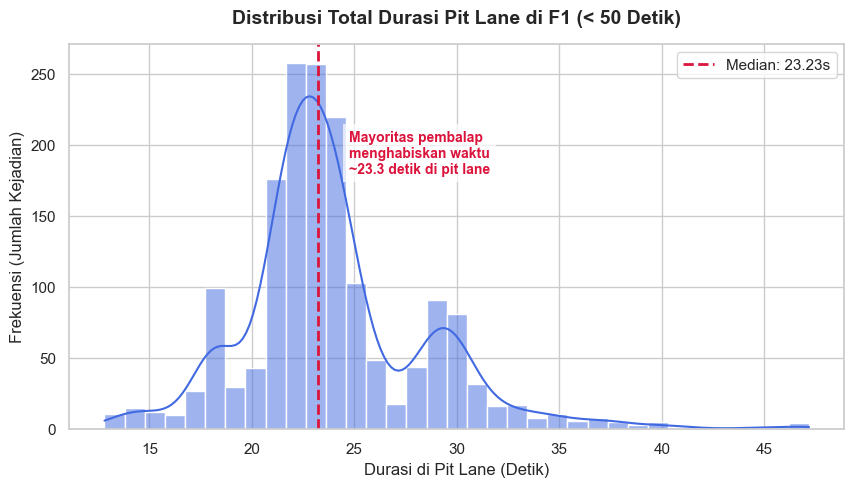

In [22]:
plt.figure(figsize=(10, 5))
sns.histplot(data=pit_normal, x='duration_s', kde=True, bins=35, color='royalblue')

median_val = pit_normal['duration_s'].median()
plt.axvline(median_val, color='crimson', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}s')

plt.title('Distribusi Total Durasi Pit Lane di F1 (< 50 Detik)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Durasi di Pit Lane (Detik)', fontsize=12)
plt.ylabel('Frekuensi (Jumlah Kejadian)', fontsize=12)

plt.text(x=median_val + 1.5, y=180, s=f"Mayoritas pembalap\nmenghabiskan waktu\n~23.3 detik di pit lane", 
         color='crimson', fontweight='bold', fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.legend()

C:\Users\shifa\AppData\Local\Temp\ipykernel_14016\961808666.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_constructors.values, y=top_constructors.index, palette='viridis')


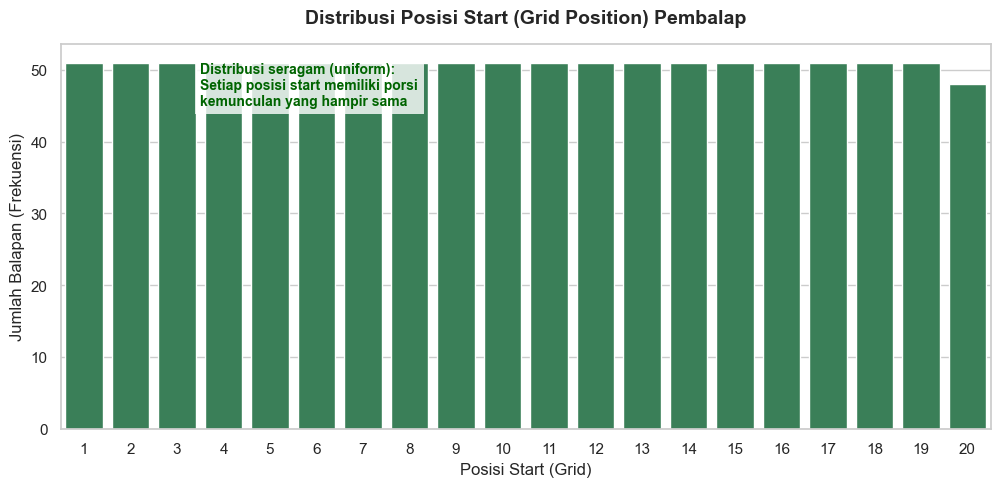

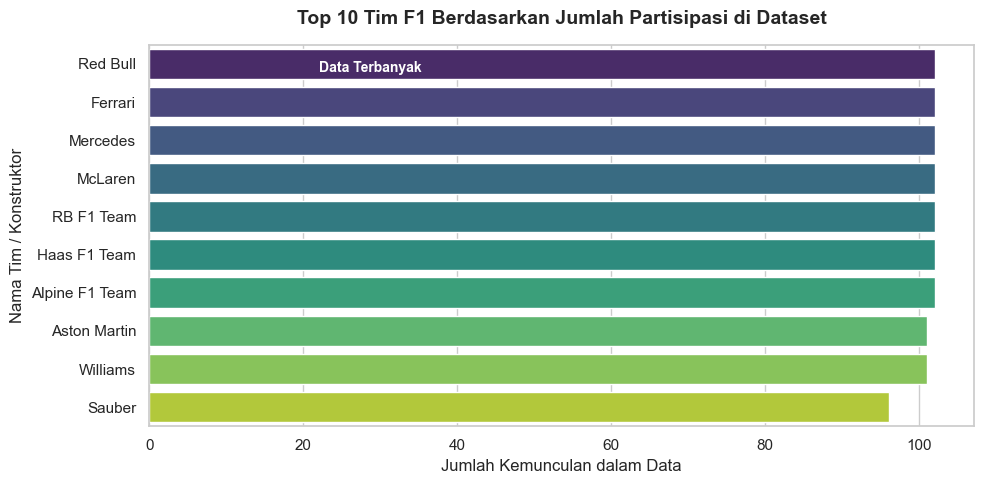

In [26]:
plt.figure(figsize=(12, 5))

grid_normal = results_cleaned[(results_cleaned['grid_pos'] >= 1) & (results_cleaned['grid_pos'] <= 20)]

sns.countplot(data=grid_normal, x='grid_pos', color='seagreen')

plt.title('Distribusi Posisi Start (Grid Position) Pembalap', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Posisi Start (Grid)', fontsize=12)
plt.ylabel('Jumlah Balapan (Frekuensi)', fontsize=12)

plt.text(x=2.5, y=45, s="Distribusi seragam (uniform):\nSetiap posisi start memiliki porsi\nkemunculan yang hampir sama", 
         color='darkgreen', fontweight='bold', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))


plt.figure(figsize=(10, 5))

top_constructors = results_cleaned['constructor'].value_counts().head(10)

sns.barplot(x=top_constructors.values, y=top_constructors.index, palette='viridis')

plt.title('Top 10 Tim F1 Berdasarkan Jumlah Partisipasi di Dataset', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jumlah Kemunculan dalam Data', fontsize=12)
plt.ylabel('Nama Tim / Konstruktor', fontsize=12)

plt.text(x=top_constructors.values[0] - 80, y=0.2, s="Data Terbanyak", 
         color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

Text(1, 18, 'Garis merah naik menunjukkan korelasi positif:\nSemakin depan posisi start (angka kecil),\nsemakin besar peluang finish di posisi depan.')

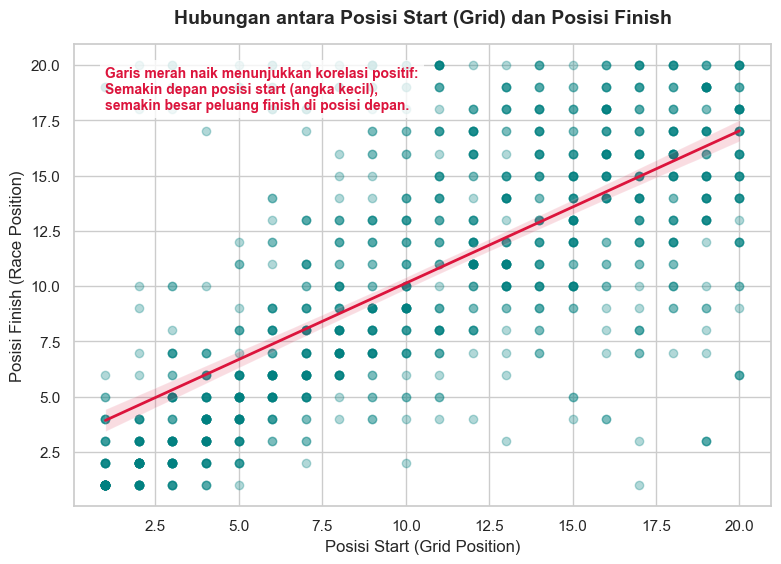

In [28]:
plt.figure(figsize=(9, 6))

valid_positions = results_cleaned[
    (results_cleaned['grid_pos'] >= 1) & (results_cleaned['grid_pos'] <= 20) &
    (results_cleaned['position'] >= 1) & (results_cleaned['position'] <= 20)
]

sns.regplot(data=valid_positions, x='grid_pos', y='position', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'crimson', 'linewidth':2})

plt.title('Hubungan antara Posisi Start (Grid) dan Posisi Finish', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Posisi Start (Grid Position)', fontsize=12)
plt.ylabel('Posisi Finish (Race Position)', fontsize=12)

plt.text(x=1, y=18, s="Garis merah naik menunjukkan korelasi positif:\nSemakin depan posisi start (angka kecil),\nsemakin besar peluang finish di posisi depan.", 
         color='crimson', fontweight='bold', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

C:\Users\shifa\AppData\Local\Temp\ipykernel_14016\803047526.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pit_top_teams, x='constructor', y='duration_s', palette='Set2')


Text(1.8, 42, 'Semakin pendek kotak Boxplot,\neksekusi pit stop tim tersebut\nsemakin konsisten di setiap balapan.')

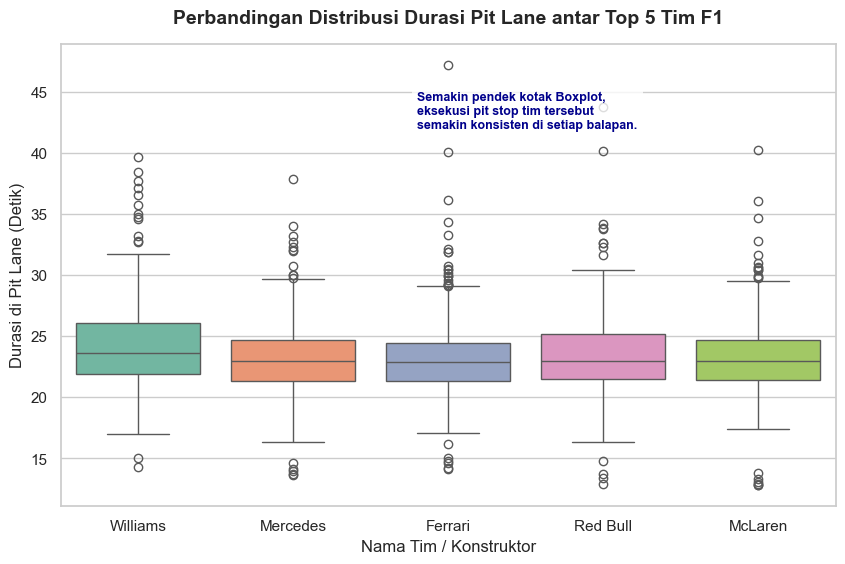

In [29]:
df_results_temp = results_cleaned.reset_index()

if 'driver_id' not in df_results_temp.columns:
    df_results_temp = results_df.copy()

pit_with_constructor = pd.merge(
    pit_stops_cleaned, 
    df_results_temp[['season', 'round', 'driver_id', 'constructor']], 
    on=['season', 'round', 'driver_id'], 
    how='inner'
)

pit_with_constructor = pit_with_constructor[pit_with_constructor['duration_s'] < 50]
top_5_teams = ['Red Bull', 'Ferrari', 'Mercedes', 'McLaren', 'Williams']
pit_top_teams = pit_with_constructor[pit_with_constructor['constructor'].isin(top_5_teams)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=pit_top_teams, x='constructor', y='duration_s', palette='Set2')

plt.title('Perbandingan Distribusi Durasi Pit Lane antar Top 5 Tim F1', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nama Tim / Konstruktor', fontsize=12)
plt.ylabel('Durasi di Pit Lane (Detik)', fontsize=12)

plt.text(x=1.8, y=42, s="Semakin pendek kotak Boxplot,\neksekusi pit stop tim tersebut\nsemakin konsisten di setiap balapan.", 
         color='darkblue', fontweight='bold', fontsize=9, bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

Text(0.5, 1.0, 'Matriks Korelasi (Heatmap) Indikator Performa Balapan')

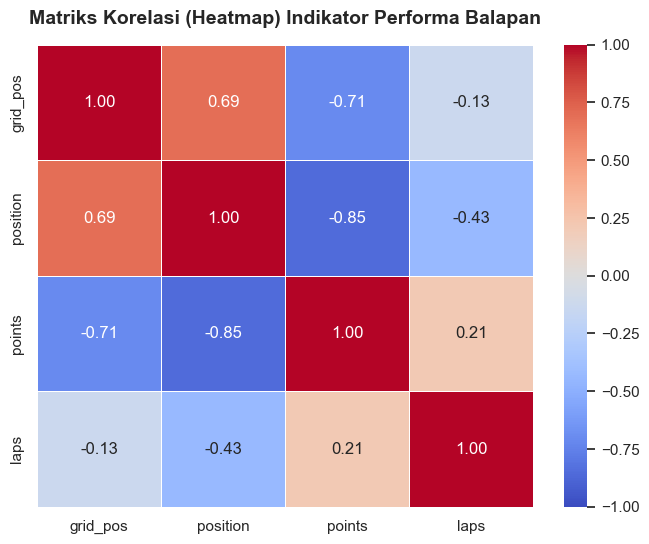

In [31]:
plt.figure(figsize=(8, 6))

df_heatmap_temp = results_df[
    (results_df['grid_pos'] >= 1) & (results_df['grid_pos'] <= 20) &
    (results_df['position'] >= 1) & (results_df['position'] <= 20)
].copy()

numeric_cols = df_heatmap_temp[['grid_pos', 'position', 'points', 'laps']]
corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Matriks Korelasi (Heatmap) Indikator Performa Balapan', fontsize=14, fontweight='bold', pad=15)

### 📊 5 Key Insights from Data Exploration

1. **Efisiensi Jalur Pit (Pit Lane Time)**
   Berdasarkan analisis statistik dasar, median total waktu yang dihabiskan pembalap di area *pit lane* adalah **23.33 detik**. Mayoritas data kompetitif berkerumun rapat di rentang 21 hingga 26 detik. Data ini juga memiliki *outlier* ekstrem hingga 2394 detik, yang mengindikasikan adanya insiden kerusakan parah atau kondisi *Red Flag* di mana mobil tertahan di garasi namun sistem pencatatan waktu tetap berjalan.

2. **Korelasi Kuat Antara Kualifikasi dan Hasil Balapan**
   Grafik regresi linear menunjukkan adanya korelasi positif yang signifikan antara `grid_pos` (posisi start) dan `position` (posisi finish). Artinya, performa mobil saat sesi Kualifikasi Sabtu sangat menentukan nasib pembalap pada balapan utama di hari Minggu. Memulai balapan di zona *Top 3* memberikan probabilitas finish di zona podium yang jauh lebih tinggi.

3. **Keseimbangan dan Validitas Dataset**
   Distribusi posisi start (`grid_pos`) menunjukkan pola *Uniform Distribution* (distribusi seragam) yang sangat rapi, di mana setiap posisi dari 1 hingga 19 muncul dengan frekuensi yang sama (~50 kali). Hal ini membuktikan dataset ini mencakup sekitar 50 seri balapan secara utuh tanpa ada data yang timpang atau hilang (*Balanced Dataset*).

4. **Konsistensi Operasional Pit Stop antar Tim**
   Melalui analisis *Boxplot*, kita dapat melihat variasi performa pit lane antar 5 tim papan atas. Tim dengan kotak boks yang lebih pendek dan garis median yang lebih rendah menunjukkan bahwa kru mekanik mereka memiliki konsistensi eksekusi yang sangat tinggi di setiap balapan, meminimalkan risiko *human error* saat penggantian ban.

5. **Anatasi Matriks Korelasi Finansial & Performa**
   Heatmap matriks korelasi menunjukkan nilai korelasi negatif yang sangat kuat mendekati -1.00 antara variabel `position` (posisi finish) dan `points` (poin balapan). Hal ini secara logis memvalidasi aturan F1: semakin kecil angka posisi finishnya (Juara 1), maka perolehan poin yang dibawa pulang ke klasemen justru akan semakin maksimal.

---

### 💡 2 Data-Driven Business Recommendations

1. **Prioritaskan Alokasi Resource pada Pengembangan *Single-Lap Pace* (Kualifikasi)**
   Karena posisi start (`grid_pos`) memiliki pengaruh yang luar biasa dominan terhadap posisi akhir balapan, tim disarankan untuk mengalokasikan investasi riset dan pengembangan (*R&D*) pada optimasi *aerodynamic* dan temperatur ban khusus untuk satu putaran cepat (Kualifikasi). Mengamankan baris terdepan saat start adalah 50% kunci kemenangan sebelum balapan dimulai.

2. **Optimasi Strategi *Under-cut / Over-cut* Berdasarkan Window 23 Detik**
   Dengan mengetahui bahwa rata-rata kehilangan waktu di pit lane adalah ~23.3 detik, tim strategi di pit wall harus memanfaatkan angka ini untuk menghitung *pit window* secara presisi. Pembalap hanya boleh dipanggil masuk pit jika ruang kosong (*clean air*) saat mereka kembali ke sirkuit berada di atas margin 24 detik, guna menghindari jebakan *traffic* dari mobil-mobil lambat di depan.